### Importing Librares

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

### Reading The Data

In [2]:
df = pd.read_csv( '../data/cleaned data/cleaned_data.csv' )

In [3]:
df.shape

(11500, 29)

In [4]:
df

,sale_id,sale_date,year,quarter,month,country,region,city,product_name,category,...,revenue_local_currency,sales_channel,payment_method,customer_segment,customer_age_group,previous_device_os,customer_rating,return_status,sale_year,price_tier
0,APPL-00000001,2022-01-03,1970,Q1,January,Argentina,South America,Buenos Aires,AirPods (3rd Gen),AirPods,...,1.343448e+05,Third-Party Retailer,Cash,Government,45–54,NaN,4.1,Kept,2022,Budget
1,APPL-00000002,2022-01-04,1970,Q1,January,Argentina,South America,Buenos Aires,USB-C Woven Charge Cable,Accessories,...,1.155971e+05,Authorized Reseller,Debit Card,Business,45–54,NaN,4.8,Kept,2022,Budget
2,APPL-00000003,2022-05-18,1970,Q2,May,Argentina,South America,Buenos Aires,Apple Watch Series 8,Apple Watch,...,1.066342e+06,Corporate / B2B,Credit Card,Individual,18–24,NaN,4.3,Kept,2022,Mid-Range
3,APPL-00000004,2022-05-23,1970,Q2,May,Argentina,South America,Buenos Aires,MacBook Pro 14-inch (M3),Mac,...,3.506045e+06,Carrier Store,Credit Card,Education,45–54,NaN,NaN,Kept,2022,Luxury
4,APPL-00000005,2022-07-13,1970,Q3,July,Argentina,South America,Buenos Aires,Apple Watch Ultra 2,Apple Watch,...,1.952780e+06,Apple Store,Net Banking,Education,18–24,NaN,NaN,Kept,2022,Premium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11495,APPL-00011496,2024-02-08,1970,Q1,February,Vietnam,Asia,Nha Trang,Apple Watch Series 9,Apple Watch,...,1.957550e+07,Third-Party Retailer,Gift Card,Individual,18–24,NaN,4.0,Kept,2024,Mid-Range
11496,APPL-00011497,2024-02-15,1970,Q1,February,Vietnam,Asia,Nha Trang,Mac Pro (M2 Ultra),Mac,...,1.663898e+08,Corporate / B2B,Gift Card,Education,45–54,NaN,4.9,Kept,2024,Luxury
11497,APPL-00011498,2024-08-28,1970,Q3,August,Vietnam,Asia,Nha Trang,iPhone 15,iPhone,...,8.657932e+07,Authorized Reseller,Debit Card,Government,35–44,iOS 16,3.8,Kept,2024,Premium
11498,APPL-00011499,2024-08-31,1970,Q3,August,Vietnam,Asia,Nha Trang,iPhone SE (3rd Gen),iPhone,...,1.075526e+07,Apple Store,EMI / Installment,Education,55+,iOS 17,NaN,Kept,2024,Mid-Range


## KPIs Section

#### 1) Total No. of Transactions
#### 2) No. of terms
#### 3) No. of Units Sold
#### 4) Avg. Price
#### 5) Total Sales 

In [9]:
# ── Feature Engineering ───────────────────────────────────────────────────────
# NOTE: Adjust column names below to match your actual dataset

# Try to detect key columns automatically
num_cols   = df.select_dtypes(include='number').columns.tolist()
cat_cols   = df.select_dtypes(include='object').columns.tolist()
date_cols  = df.select_dtypes(include='datetime').columns.tolist()

print(f' Numeric columns  : {num_cols}')
print(f' Categorical cols : {cat_cols}')
print(f' Date columns     : {date_cols}')

# Revenue per unit (if both exist)
if 'revenue' in df.columns and 'units_sold' in df.columns:
    df['revenue_per_unit'] = df['revenue'] / df['units_sold'].replace(0, np.nan)

# Year extraction
for dc in date_cols:
    df[dc.replace('date','year')] = df[dc].dt.year

# Price buckets (if price column exists)
price_col = next((c for c in df.columns if 'price' in c), None)
if price_col:
    df['price_tier'] = pd.qcut(df[price_col].dropna(), q=4,
                                labels=['Budget','Mid-Range','Premium','Luxury'])

print('\n Feature engineering complete!')

 Numeric columns  : ['year', 'unit_price_usd', 'discount_pct', 'units_sold', 'discounted_price_usd', 'revenue_usd', 'fx_rate_to_usd', 'revenue_local_currency', 'customer_rating', 'sale_year']
 Categorical cols : ['sale_id', 'sale_date', 'quarter', 'month', 'country', 'region', 'city', 'product_name', 'category', 'storage', 'color', 'currency', 'sales_channel', 'payment_method', 'customer_segment', 'customer_age_group', 'previous_device_os', 'return_status', 'price_tier']
 Date columns     : []

 Feature engineering complete!


In [10]:
# ── Exact Column Mappings ─────────────────────────────────────────────────────
cat_col   = 'category'              # product category
prod_col  = 'product_name'          # individual product name
rev_col   = 'revenue_usd'           # revenue
units_col = 'units_sold'            # units sold
price_col = 'unit_price_usd'        # price
geo_col   = 'country'               # country
region_col= 'region'                # region
year_col  = 'year'                  # year
quarter_col = 'quarter'             # quarter
month_col = 'month'                 # month
channel_col = 'sales_channel'       # sales channel
segment_col = 'customer_segment'    # customer segment
rating_col  = 'customer_rating'     # customer rating
return_col  = 'return_status'       # return status
age_col     = 'customer_age_group'  # age group
color_col   = 'color'               # color
storage_col = 'storage'             # storage
payment_col = 'payment_method'      # payment method
os_col      = 'previous_device_os'  # previous device OS

C:\Users\Admin\AppData\Local\Temp\ipykernel_7120\2240930889.py:36: UserWarning: Glyph 127822 (\N{RED APPLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_7120\2240930889.py:36: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_7120\2240930889.py:36: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_7120\2240930889.py:36: UserWarning: Glyph 128241 (\N{MOBILE PHONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


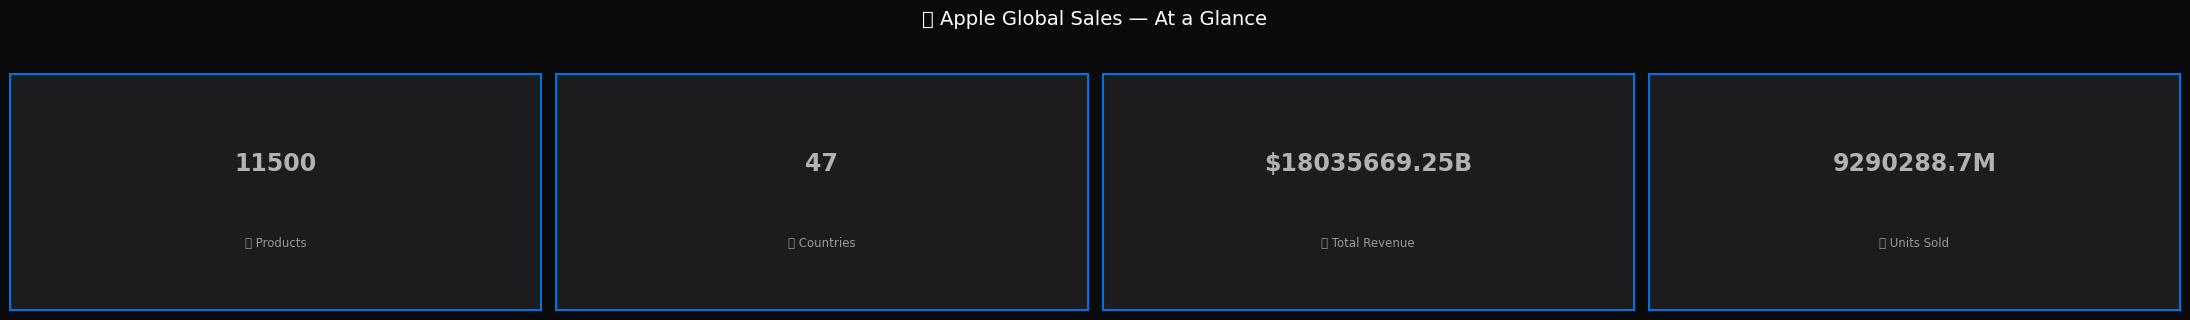

In [ ]:
# ── KPI Summary Cards ─────────────────────────────────────────────────────────
# Adapt metric names to your actual columns
total_records  = len(df)
total_products = df[cat_cols[0]].nunique() if cat_cols else 'N/A'
total_countries= df[[c for c in df.columns if 'country' in c or 'region' in c][0]].nunique() \
                 if any('country' in c or 'region' in c for c in df.columns) else 'N/A'

# Revenue KPI
rev_col = next((c for c in df.columns if 'revenue' in c or 'sales' in c), None)
total_rev = f'${df[rev_col].sum()}B' if rev_col else 'N/A'

# Units KPI
units_col = next((c for c in df.columns if 'unit' in c or 'quantity' in c or 'sold' in c), None)
total_units = f'{df[units_col].sum()}M' if units_col else 'N/A'

metrics = [
    ('🍎 Products',        str(total_products)),
    ('🌍 Countries',       str(total_countries)),
    ('💰 Total Revenue',   total_rev),
    ('📱 Units Sold',      total_units),
]

fig, axes = plt.subplots(1, 4, figsize=(22, 3))
fig.patch.set_facecolor('#0a0a0a')
for ax, (label, value) in zip(axes, metrics):
    ax.set_facecolor('#1c1c1e')
    ax.text(0.5, 0.62, value, ha='center', va='center', fontsize=17,
            fontweight='bold', color="#b0b2b4", transform=ax.transAxes)
    ax.text(0.5, 0.28, label, ha='center', va='center', fontsize=8.5,
            color='#98989d', transform=ax.transAxes)
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor('#0071e3'); spine.set_linewidth(1.5)

plt.suptitle(' Apple Global Sales — At a Glance', fontsize=14, color='white', y=1.05)
plt.tight_layout()
plt.show()
